### Goal 

Preprocessing the data from previous labs (africa galore dataset), then training a transformer model

### Tasks 

- Load the dataset, tokenize it, and convert it to token IDs.
- Pad the dataset such that all sequences have the same length.
- Shuffle the examples in the dataset and group them into batches.
- Transform the data into model inputs and model targets.
- Train the transformer model.

In [1]:
import os
import pandas as pd
import tensorflow as tf
from utils.simple_word_tokenizer import SimpleWordTokenizer
from utils.slm_model import create_slm_model, TextGenerationCallback, TextGenerator
# Setting up TensorFlow to use the GPU if available.
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU is available and configured for TensorFlow.")
    except RuntimeError as e:
        print(e)
else:
    print("GPU is not available. TensorFlow will use the CPU.")

GPU is available and configured for TensorFlow.


In [2]:
africa_galore = pd.read_json("__assets/africa_galore.json")
dataset = africa_galore["description"].values
print("Loaded dataset with", dataset.shape[0], "paragraphs.")

Loaded dataset with 232 paragraphs.


In [3]:
swt = SimpleWordTokenizer() # Check this class in utils/simple_word_tokenizer.py for details on how it works.
swt.adapt(corpus=dataset) 

encoded_tokens = []
for text in dataset: 
    token_ids = swt.encode(text)
    encoded_tokens.append(token_ids)
encoded_tokens[0][:10]

[813, 510, 984, 5091, 4801, 5182, 2799, 1362, 4791, 2133]

In [4]:
# Check the shortest and longest paragraphs. 
lengths = [len(tokens) for tokens in encoded_tokens]
print("Shortest paragraph has", min(lengths), "tokens.")
print("Longest paragraph has", max(lengths), "tokens.")

Shortest paragraph has 26 tokens.
Longest paragraph has 318 tokens.


In [5]:
max_length = 256
padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    encoded_tokens,
    maxlen=max_length, # Truncate sequences longer than this length. 
    padding='post', # Pad with zeros at the end of the sequence.
    truncating='post', # Truncate sequences longer than max_length at the end.
    value = swt.pad_token_id
) # Goal is to make all sequences the same length for batch processing.
print("Padded sequences shape:", padded_sequences.shape)

Padded sequences shape: (232, 256)


In [6]:
input_sequences = padded_sequences[:, :-1] # All tokens except the last one.
target_sequences = padded_sequences[:, 1:] # All tokens except the first one.
print("Input sequences shape:", input_sequences.shape)
print("Target sequences shape:", target_sequences.shape)

Input sequences shape: (232, 255)
Target sequences shape: (232, 255)


In [7]:
tf_dataset = tf.data.Dataset.from_tensor_slices((input_sequences, target_sequences))
tf_dataset = tf_dataset.shuffle(buffer_size=input_sequences.shape[0]).batch(32) # Shuffle and batch

for batch in tf_dataset.take(1):
    print("Input batch shape:", batch[0].shape)
    print("Target batch shape:", batch[1].shape)

Input batch shape: (32, 255)
Target batch shape: (32, 255)


2026-02-23 12:00:19.792676: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-02-23 12:00:19.792697: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-02-23 12:00:19.792702: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2026-02-23 12:00:19.792716: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 12:00:19.792725: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-02-23 12:00:19.817247: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
total_batches = 0 
for batch in tf_dataset:
    total_batches += 1
print("Total batches in the dataset:", total_batches)

Total batches in the dataset: 8


2026-02-23 12:00:19.825303: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Preparing the SLM model: The structure is defined in utils/slm_model.py

In [9]:
model = create_slm_model(maxlen=max_length-1, vocab_size=swt.vocabulary_size, embed_dim=256, num_heads=2, ff_dim=256, pad_token_id=swt.pad_token_id)
model.summary()

Model: "slm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 255)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 255, 256)       │     1,412,096 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 255, 256)       │       658,688 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 255, 5261)      │     1,352,077 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,422,861 (13.06 MB)

 Trainable params: 3,422,861 (13.06 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
num_epochs = 200 # You can increase this. 
callback = TextGenerationCallback("Africa is", swt, max_tokens=50, every_n_epochs= 20, temperature = 1) 
history = model.fit(tf_dataset, verbose=0, epochs= num_epochs, callbacks=[callback])

--- Epoch 20 / 200 | Loss: 0.2632357180118561 | Time: 0.00s | Generated text ---
Africa is a a tangy West Africa, drink popular in a fermented corn and North Africa, particularly in a East Africa simmered until golden brown. The drink popular in a hearty and dried corn dough that balances the Sahel, and savory and baked until set and a quick, flavorful sauce, and a
---
--- Epoch 40 / 200 | Loss: 0.23221710324287415 | Time: 13.95s | Generated text ---
Africa is is a popular in a drink popular in a fermented corn and nutritious drink is fermented drink is commonly served in a soothing remedy for extra Ali peri-peri chili for a spicy curry, often brewed and thick, slightly viscous soup. It can be served with a faint sweetness. Rich in
---
--- Epoch 60 / 200 | Loss: 0.2074163556098938 | Time: 13.98s | Generated text ---
Africa is a a naturally a fermented buns spiced rice and refreshing drink has a quest for its soothing effect. The result is traditionally served tortilis), the base, slow 

Still does not quite make sense, perhaps info about how africa is does not exist in the database. 

In [33]:
generator_class = TextGenerator(model, swt, temperature=0.7)
prompt = "Mount Kilimanjaro"
num_tokens_to_generate = 20
generated_text, probabilities = generator_class.generate(prompt, num_tokens_to_generate)
generated_text

'Mount Kilimanjaro holds the most elusive the children, dressed in the Great Escarpment, which the liquid. Popular in the name means "farmer\'s'

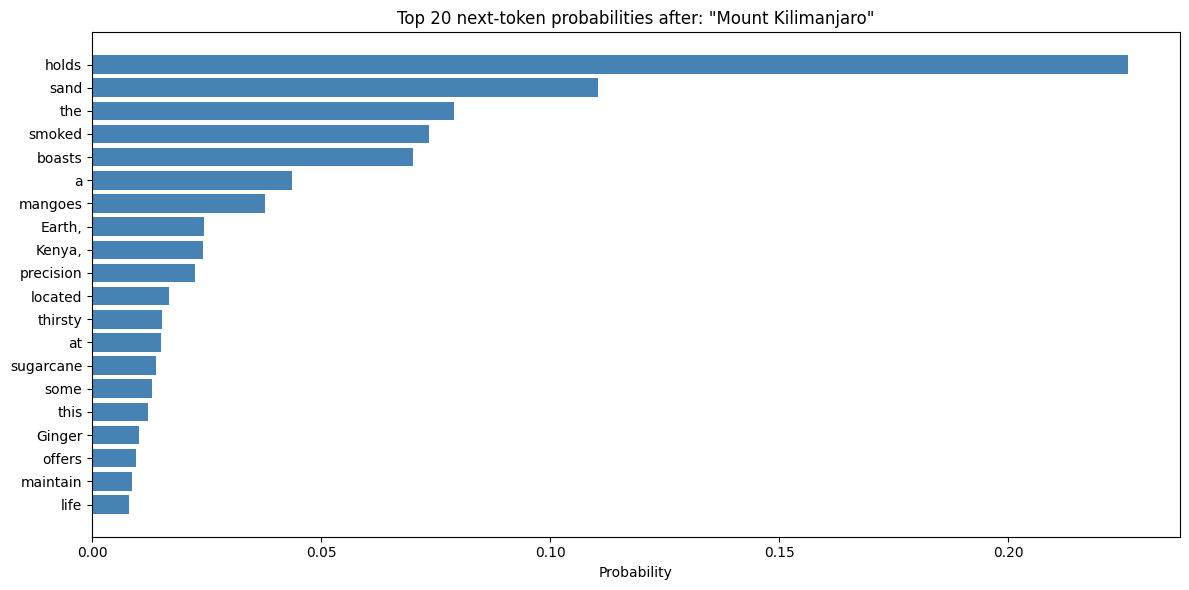

In [34]:
import matplotlib.pyplot as plt

# Get all_probabilities for the first generated token (next word after the prompt)
all_probs = probabilities[0]["all_probabilities"]

# Sort by probability descending and take top 20
sorted_probs = sorted(all_probs.items(), key=lambda x: x[1], reverse=True)[:20]
tokens, probs = zip(*sorted_probs)

plt.figure(figsize=(12, 6))
plt.barh(range(len(tokens)), probs, color="steelblue")
plt.yticks(range(len(tokens)), tokens)
plt.gca().invert_yaxis()  # Highest probability on top
plt.xlabel("Probability")
plt.title(f'Top 20 next-token probabilities after: "{prompt}"')
plt.tight_layout()
plt.show()

Still need better and more training for better results.